Hacemos los imports 

In [10]:
import sys
!{sys.executable} -m pip install tensorflow
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install seaborn
!{sys.executable} -m pip install scikit-learn




[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import tensorflow as tf
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [12]:
df = pd.read_csv("dataset.csv")

campos_borrar = ['Class', 'Brand', 'Acquisition', 'Concentration', 'Concentration_Class']

X = df.drop(campos_borrar, axis = 1)
y = df['Class']

#Para el XGBoost hay que hacer esto para que las clases sean un número y cambiarla en la asignación
le = LabelEncoder()
y_raw = le.fit_transform(y)
#print(y)

X_train, X_test, y_train, y_test = train_test_split(X , y_raw ,test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype('float32')
X_test_scaled = scaler.transform(X_test).astype('float32')

#Neuronas capa de salida
num_clases = len(np.unique(y_train))

In [13]:
def create_dataset(X, y, batch_size=128, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((X,y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X))
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [14]:
train_ds = create_dataset(X_train_scaled, y_train)
test_ds = create_dataset(X_test_scaled, y_test, shuffle=False)

Iniciando entrenamiento...
Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.2154 - loss: 2.1355 - val_accuracy: 0.2333 - val_loss: 2.0662 - learning_rate: 0.0010
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2394 - loss: 2.0273 - val_accuracy: 0.2480 - val_loss: 2.0004 - learning_rate: 0.0010
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2476 - loss: 2.0024 - val_accuracy: 0.2529 - val_loss: 1.9850 - learning_rate: 0.0010
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2521 - loss: 1.9903 - val_accuracy: 0.2545 - val_loss: 1.9842 - learning_rate: 0.0010
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2531 - loss: 1.9829 - val_accuracy: 0.2604 - val_loss: 1.9635 - learning_rate: 0.0010
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2536 - loss: 1.9797 - val_accuracy: 0.2545 - val_loss: 1.9794 - learning_rate: 0.0010
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accurac

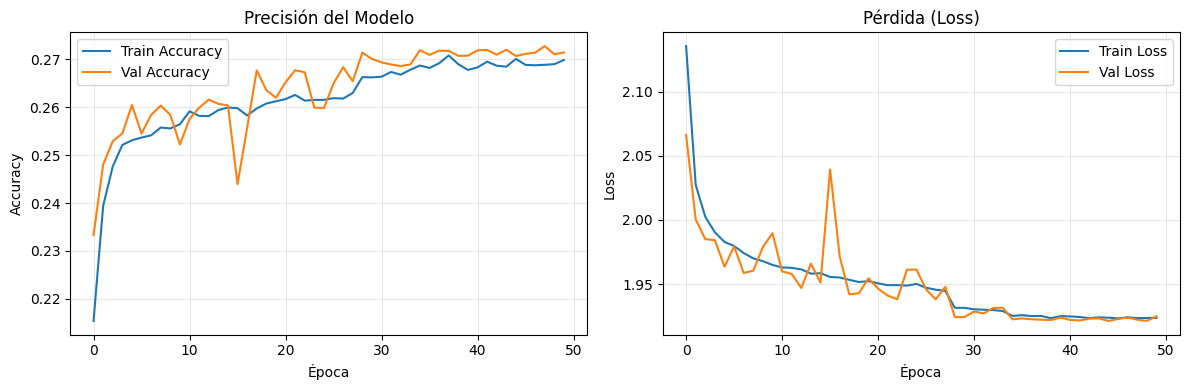


EVALUACIÓN EN TEST

Loss:     1.9213
Accuracy: 0.2706  (27.06%)

REPORTE POR CLASE
              precision    recall  f1-score   support

           0      1.000     0.000     0.001      2766
           1      0.268     0.291     0.279      4100
           2      0.146     0.141     0.144      2661
           3      0.561     0.644     0.600      4514
           4      0.208     0.448     0.284      4177
           5      0.174     0.223     0.196      2015
           6      0.144     0.180     0.160      2112
           7      0.133     0.008     0.016      2167
           8      0.136     0.035     0.055      2045
           9      0.281     0.504     0.361      1470
          10      0.138     0.011     0.020      1510
          11      0.518     0.214     0.303       463

    accuracy                          0.271     30000
   macro avg      0.309     0.225     0.201     30000
weighted avg      0.325     0.271     0.233     30000



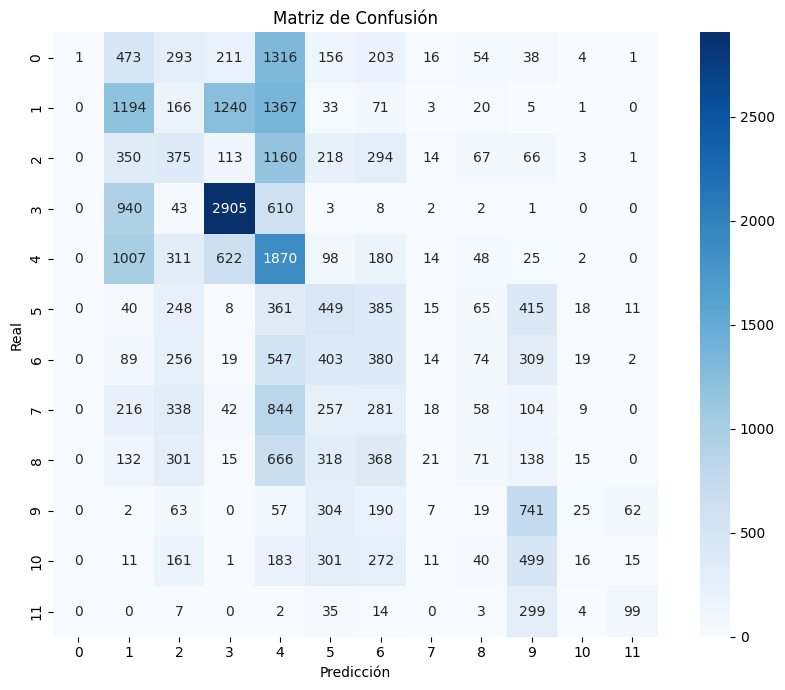

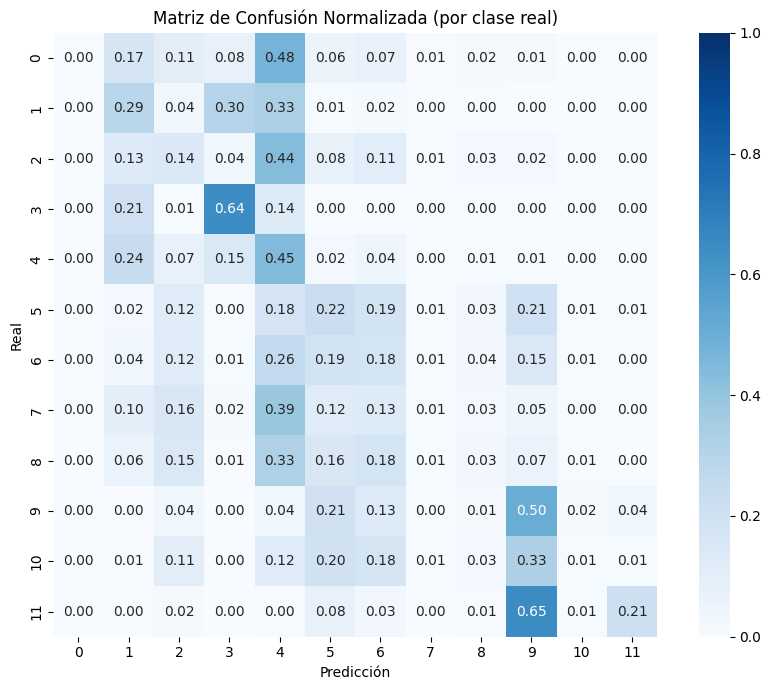


CONFIANZA DEL MODELO
Confianza media cuando acierta: 0.367
Confianza media cuando falla:   0.235


In [15]:
model = tf.keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    #Capa 1:
    layers.Dense(512, kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    
    #Capa 2:                            # Regularización contra overfitting
    layers.Dense(256, kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.2),
    
    #Capa 3:
    layers.Dense(128, kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.3),
    
    #Capa de salida
    layers.Dense(num_clases, activation='softmax')    # Softmax para multiclase
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Checpoints para guardar el mejor resultado
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "mejor_resultado.keras",
    save_best_only=True,
    monitor="val_loss",
    mode="min"
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6
    ),
    checkpoint_cb
]

# Calcular pesos basados en y_train
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

print("Iniciando entrenamiento...")
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

# Curbas de entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("EVALUACIÓN EN TEST")
print("="*60)

loss, accuracy = model.evaluate(test_ds, verbose=0)
print(f"\nLoss:     {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)")

# Predicciones
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Métricas por clase
print("\n" + "="*60)
print("REPORTE POR CLASE")
print("="*60)
print(classification_report(y_true, y_pred, digits=3))

# Matroz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    square=True
)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    cbar=True,
    square=True,
    vmin=0,
    vmax=1
)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión Normalizada (por clase real)')
plt.tight_layout()
plt.show()

confianzas = np.max(y_pred_probs, axis=1)
aciertos = (y_pred == y_true)

print("\n" + "="*60)
print("CONFIANZA DEL MODELO")
print("="*60)
print(f"Confianza media cuando acierta: {confianzas[aciertos].mean():.3f}")
print(f"Confianza media cuando falla:   {confianzas[~aciertos].mean():.3f}")